# IoT Device-Type Classification — Packet-Feature Windows (DL, RAW vs MASKED)

This notebook runs DL on **packet-feature windows** (sequence features) and compares RAW vs MASKED (ports zeroed).

In [1]:
# 1) Imports & configuration
import os, glob, time, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization

from scapy.all import PcapReader, IP, TCP, UDP

RANDOM_STATE = 43
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

PCAP_DATA_GLOB = "unsw-dataset/pcaps/*.pcap"

PKTS_PER_WINDOW = 60
STRIDE = 60
MAX_WINDOWS_PER_DEVICE = 1200

BATCH_SIZE = 256
EPOCHS = 8
SHUFFLE_BUF = 8000

DEVICE_IP_SCAN_PKTS = 200
IAT_CAP_SECONDS = 10.0


2026-01-14 15:04:37.720679: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-14 15:04:38.254967: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-14 15:04:41.443395: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# 2) Device -> type mapping
device_to_type = {
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

pcap_files = sorted(glob.glob(PCAP_DATA_GLOB))
rows = []
for fp in pcap_files:
    dev = os.path.basename(fp).replace(".pcap", "")
    if dev in device_to_type:
        rows.append({"device": dev, "device_type": device_to_type[dev], "pcap_path": fp})
df_pcaps = pd.DataFrame(rows)
print("PCAPs used:", len(df_pcaps))
display(df_pcaps["device_type"].value_counts().to_frame("n_pcaps"))


PCAPs used: 25


,n_pcaps
device_type,
camera_streamer,8
sensor_meter,6
media_speaker_display,5
actuator_light_plug,4
hub_gateway_bridge,2


In [3]:
# 3) Device-level split
devices = df_pcaps["device"].tolist()
types = df_pcaps["device_type"].tolist()
train_devs, test_devs = train_test_split(devices, test_size=0.30, random_state=RANDOM_STATE, stratify=types)

df_train = df_pcaps[df_pcaps["device"].isin(train_devs)].reset_index(drop=True)
df_test  = df_pcaps[df_pcaps["device"].isin(test_devs)].reset_index(drop=True)

type_classes = sorted(df_pcaps["device_type"].unique())
type_to_idx = {t:i for i,t in enumerate(type_classes)}
idx_to_type = {i:t for t,i in type_to_idx.items()}

print("Train devices:", df_train["device"].nunique(), "| Test devices:", df_test["device"].nunique())
print("Type classes:", type_classes)


Train devices: 17 | Test devices: 8
Type classes: ['actuator_light_plug', 'camera_streamer', 'hub_gateway_bridge', 'media_speaker_display', 'sensor_meter']


In [4]:
# 4) Feature extraction (F=17)
F_DIM = 17

def infer_device_ip(pcap_path, scan_packets=200):
    counts = {}
    seen = 0
    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            if not pkt.haslayer(IP):
                continue
            src = pkt[IP].src
            counts[src] = counts.get(src, 0) + 1
            seen += 1
            if seen >= scan_packets:
                break
    return max(counts.items(), key=lambda kv: kv[1])[0] if counts else None

def tcp_flag_bits(tcp_layer):
    f = int(tcp_layer.flags)
    return np.array([
        1.0 if (f & 0x01) else 0.0,
        1.0 if (f & 0x02) else 0.0,
        1.0 if (f & 0x04) else 0.0,
        1.0 if (f & 0x08) else 0.0,
        1.0 if (f & 0x10) else 0.0,
        1.0 if (f & 0x20) else 0.0,
    ], dtype=np.float32)

def safe_payload_len(pkt):
    try:
        return max(0, len(bytes(pkt.payload)))
    except Exception:
        return 0

def featurize_packet(pkt, prev_time, device_ip=None, masked=False):
    try:
        this_time = float(getattr(pkt, "time", 0.0))
        if prev_time is None or this_time <= 0.0 or prev_time <= 0.0:
            iat = 0.0
        else:
            iat = max(0.0, this_time - prev_time)
        iat = min(iat, IAT_CAP_SECONDS)

        pkt_len = float(len(pkt))
        payload_len = float(safe_payload_len(pkt))

        direction = 0.0
        ttl = 0.0
        proto_oh = np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float32)
        flags = np.zeros(6, dtype=np.float32)
        sport = 0.0
        dport = 0.0

        if pkt.haslayer(IP):
            ip = pkt[IP]
            ttl = float(getattr(ip, "ttl", 0))
            direction = 1.0 if (device_ip is not None and getattr(ip, "src", None) == device_ip) else 0.0
            proto = int(getattr(ip, "proto", 0))
            if proto == 6:
                proto_oh = np.array([1.0, 0.0, 0.0, 0.0], dtype=np.float32)
            elif proto == 17:
                proto_oh = np.array([0.0, 1.0, 0.0, 0.0], dtype=np.float32)
            elif proto == 1:
                proto_oh = np.array([0.0, 0.0, 1.0, 0.0], dtype=np.float32)
            else:
                proto_oh = np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float32)

        if pkt.haslayer(TCP):
            tcp = pkt[TCP]
            flags = tcp_flag_bits(tcp)
            sport = float(getattr(tcp, "sport", 0))
            dport = float(getattr(tcp, "dport", 0))
        elif pkt.haslayer(UDP):
            udp = pkt[UDP]
            sport = float(getattr(udp, "sport", 0))
            dport = float(getattr(udp, "dport", 0))

        if masked:
            sport, dport = 0.0, 0.0

        pkt_len_norm = min(pkt_len / 1500.0, 2.0)
        payload_norm = min(payload_len / 1500.0, 2.0)
        ttl_norm = ttl / 255.0
        sport_norm = sport / 65535.0
        dport_norm = dport / 65535.0
        iat_norm = math.log1p(iat) / math.log1p(IAT_CAP_SECONDS)

        feat = np.concatenate([
            np.array([pkt_len_norm, payload_norm, iat_norm, direction, ttl_norm], dtype=np.float32),
            proto_oh,
            flags,
            np.array([sport_norm, dport_norm], dtype=np.float32),
        ], axis=0)

        return (feat if feat.shape[0] == F_DIM else None), this_time
    except Exception:
        return None, float(getattr(pkt, "time", 0.0))


In [5]:
# 5) Window generator (feature windows)
def iter_feature_windows(df_subset, masked=False):
    order = df_subset.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
    for _, row in order.iterrows():
        y = type_to_idx[row["device_type"]]
        pcap_path = row["pcap_path"]
        dev_ip = infer_device_ip(pcap_path, scan_packets=DEVICE_IP_SCAN_PKTS)

        buf = []
        produced = 0
        prev_time = None
        with PcapReader(pcap_path) as pcap:
            for pkt in pcap:
                feat, this_time = featurize_packet(pkt, prev_time, device_ip=dev_ip, masked=masked)
                prev_time = this_time if this_time > 0 else prev_time
                if feat is None:
                    continue
                buf.append(feat)
                if len(buf) == PKTS_PER_WINDOW:
                    yield np.stack(buf, axis=0), np.int64(y)
                    produced += 1
                    if produced >= MAX_WINDOWS_PER_DEVICE:
                        break
                    buf = [] if STRIDE >= PKTS_PER_WINDOW else buf[STRIDE:]

g = iter_feature_windows(df_train, masked=False)
x, y = next(g)
print("Sanity:", x.shape, int(y), idx_to_type[int(y)])


Sanity: (60, 17) 0 actuator_light_plug


In [ ]:
# 6) tf.data datasets
def make_dataset(df_subset, masked=False, repeat=False, shuffle_buf=8000):
    output_signature = (
        tf.TensorSpec(shape=(PKTS_PER_WINDOW, F_DIM), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64),
    )
    ds = tf.data.Dataset.from_generator(lambda: iter_feature_windows(df_subset, masked=masked),
                                        output_signature=output_signature)
    if shuffle_buf and shuffle_buf > 0:
        ds = ds.shuffle(shuffle_buf, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    if repeat:
        ds = ds.repeat()
    return ds.batch(BATCH_SIZE).prefetch(1)

ds_train_raw  = make_dataset(df_train, masked=False, repeat=True,  shuffle_buf=SHUFFLE_BUF)
ds_test_raw   = make_dataset(df_test,  masked=False, repeat=False, shuffle_buf=0)
ds_train_mask = make_dataset(df_train, masked=True,  repeat=True,  shuffle_buf=SHUFFLE_BUF)
ds_test_mask  = make_dataset(df_test,  masked=True,  repeat=False, shuffle_buf=0)

max_train_windows = df_train["device"].nunique() * MAX_WINDOWS_PER_DEVICE
steps_per_epoch = min(600, int(np.ceil(max_train_windows / BATCH_SIZE)))

print("steps_per_epoch:", steps_per_epoch)


steps_per_epoch: 80


2026-01-14 15:04:43.217673: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
# 7) 1D CNN model
def make_1d_cnn(n_classes: int):
    m = Sequential([
        Input(shape=(PKTS_PER_WINDOW, F_DIM)),
        Conv1D(64, 3, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),
        Conv1D(128, 3, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),
        Conv1D(256, 3, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.35),
        Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m


In [8]:
# 8) Train & evaluate — FEATURES-RAW vs FEATURES-MASKED
tf.keras.backend.clear_session()
model_raw = make_1d_cnn(len(type_classes))
t0 = time.time()
hist_raw = model_raw.fit(ds_train_raw, epochs=EPOCHS, steps_per_epoch=steps_per_epoch, verbose=1)
raw_time = time.time() - t0
raw_loss, raw_acc = model_raw.evaluate(ds_test_raw, verbose=0)

tf.keras.backend.clear_session()
model_mask = make_1d_cnn(len(type_classes))
t0 = time.time()
hist_mask = model_mask.fit(ds_train_mask, epochs=EPOCHS, steps_per_epoch=steps_per_epoch, verbose=1)
mask_time = time.time() - t0
mask_loss, mask_acc = model_mask.evaluate(ds_test_mask, verbose=0)

print(f"FEATURES-RAW  accuracy: {raw_acc:.4f} | train_time: {raw_time:.1f}s")
print(f"FEATURES-MASK accuracy: {mask_acc:.4f} | train_time: {mask_time:.1f}s")


Epoch 1/8


2026-01-14 15:04:56.345831: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 294 of 8000
2026-01-14 15:05:16.359633: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 869 of 8000
2026-01-14 15:05:36.353622: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 1444 of 8000
2026-01-14 15:05:46.360688: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 1770 of 8000
2026-01-14 15:06:06.338763: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 2468 of 8000
2026-01-14 15:06:16.340478: I tensorf

80/80 ━━━━━━━━━━━━━━━━━━━━ 730s 6s/step - accuracy: 0.9008 - loss: 0.3512
Epoch 2/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 591s 7s/step - accuracy: 0.9874 - loss: 0.0447
Epoch 3/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 499s 6s/step - accuracy: 0.9933 - loss: 0.0238
Epoch 4/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 489s 6s/step - accuracy: 0.9965 - loss: 0.0135
Epoch 5/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 477s 6s/step - accuracy: 0.9969 - loss: 0.0093
Epoch 6/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 556s 7s/step - accuracy: 0.9982 - loss: 0.0075
Epoch 7/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 479s 6s/step - accuracy: 0.9984 - loss: 0.0052
Epoch 8/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 529s 7s/step - accuracy: 0.9995 - loss: 0.0028


2026-01-14 16:20:53.318948: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 1/8


2026-01-14 16:21:06.361349: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:12,RepeatDataset:13): Filling up shuffle buffer (this may take a while): 343 of 8000
2026-01-14 16:21:16.361855: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:12,RepeatDataset:13): Filling up shuffle buffer (this may take a while): 650 of 8000
2026-01-14 16:21:36.358074: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:12,RepeatDataset:13): Filling up shuffle buffer (this may take a while): 1331 of 8000
2026-01-14 16:21:56.359433: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:12,RepeatDataset:13): Filling up shuffle buffer (this may take a while): 2119 of 8000
2026-01-14 16:22:16.367395: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:12,RepeatDataset:13): Filling up shuffle buffer (this may take a while): 2948 of 8000
2026-01-14 16:22:36.343917:

80/80 ━━━━━━━━━━━━━━━━━━━━ 760s 7s/step - accuracy: 0.8938 - loss: 0.3708
Epoch 2/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 460s 6s/step - accuracy: 0.9861 - loss: 0.0480
Epoch 3/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 499s 6s/step - accuracy: 0.9933 - loss: 0.0245
Epoch 4/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 561s 7s/step - accuracy: 0.9961 - loss: 0.0145
Epoch 5/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 520s 7s/step - accuracy: 0.9986 - loss: 0.0055
Epoch 6/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 590s 7s/step - accuracy: 0.9981 - loss: 0.0066
Epoch 7/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 835s 10s/step - accuracy: 0.9989 - loss: 0.0047
Epoch 8/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 1001s 13s/step - accuracy: 0.9990 - loss: 0.0034
FEATURES-RAW  accuracy: 0.2922 | train_time: 4349.0s
FEATURES-MASK accuracy: 0.1829 | train_time: 5225.5s


2026-01-14 17:55:33.784486: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


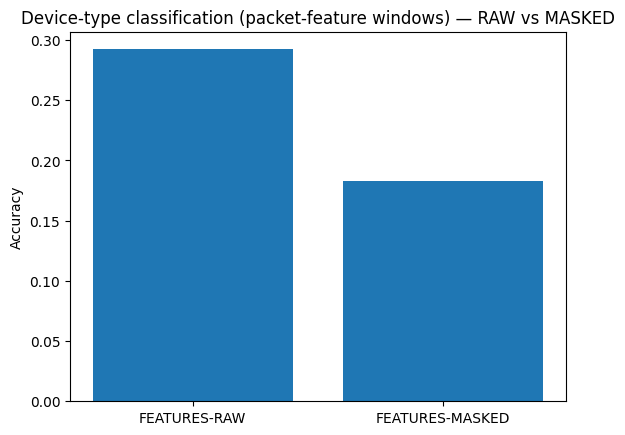

In [9]:
# 9) Quick comparison plot
plt.figure()
plt.bar(["FEATURES-RAW", "FEATURES-MASKED"], [raw_acc, mask_acc])
plt.ylabel("Accuracy")
plt.title("Device-type classification (packet-feature windows) — RAW vs MASKED")
plt.show()


2026-01-14 18:10:54.274089: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


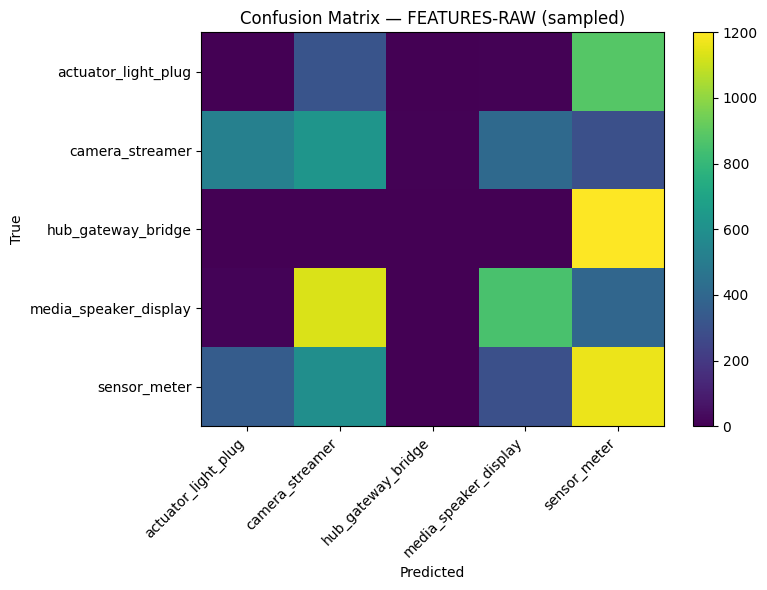

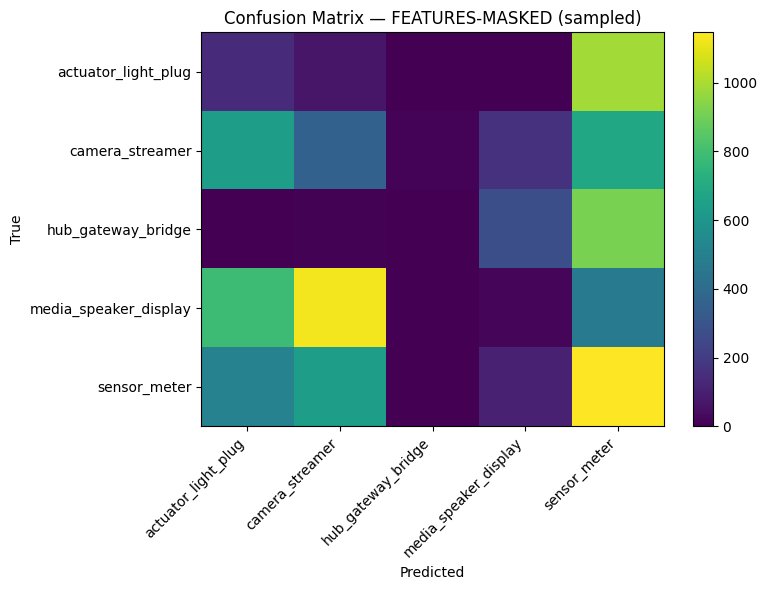


Classification report (FEATURES-RAW, sampled):
                       precision    recall  f1-score   support

  actuator_light_plug       0.00      0.00      0.00      1200
      camera_streamer       0.23      0.34      0.28      1851
   hub_gateway_bridge       0.00      0.00      0.00      1200
media_speaker_display       0.55      0.36      0.43      2400
         sensor_meter       0.30      0.48      0.37      2400

             accuracy                           0.29      9051
            macro avg       0.22      0.24      0.22      9051
         weighted avg       0.27      0.29      0.27      9051


Classification report (FEATURES-MASKED, sampled):
                       precision    recall  f1-score   support

  actuator_light_plug       0.07      0.11      0.08      1200
      camera_streamer       0.16      0.19      0.18      1851
   hub_gateway_bridge       0.00      0.00      0.00      1200
media_speaker_display       0.03      0.01      0.01      2400
         sensor

In [10]:
# 10) Sampled confusion matrices & reports
def sample_preds(ds_test, model, max_batches=150):
    y_true, y_pred = [], []
    for xb, yb in ds_test.take(max_batches):
        probs = model.predict(xb, verbose=0)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(np.argmax(probs, axis=1).tolist())
    return y_true, y_pred

ytrue_raw, ypred_raw = sample_preds(ds_test_raw, model_raw, max_batches=150)
ytrue_mask, ypred_mask = sample_preds(ds_test_mask, model_mask, max_batches=150)

cm_raw = confusion_matrix(ytrue_raw, ypred_raw, labels=list(range(len(type_classes))))
cm_mask = confusion_matrix(ytrue_mask, ypred_mask, labels=list(range(len(type_classes))))

def plot_cm(cm, title):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, aspect="auto")
    plt.xticks(range(len(type_classes)), type_classes, rotation=45, ha="right")
    plt.yticks(range(len(type_classes)), type_classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_cm(cm_raw,  "Confusion Matrix — FEATURES-RAW (sampled)")
plot_cm(cm_mask, "Confusion Matrix — FEATURES-MASKED (sampled)")

print("\nClassification report (FEATURES-RAW, sampled):")
print(classification_report(ytrue_raw, ypred_raw, target_names=type_classes))

print("\nClassification report (FEATURES-MASKED, sampled):")
print(classification_report(ytrue_mask, ypred_mask, target_names=type_classes))
